# Data Exploration — Détection d'anomalies IoT

Ce notebook couvre l'exploration complète des 9 appareils (REF, CONG, ETUVE) avant toute étape de nettoyage/modélisation.

Objectifs :
- Charger les données brutes de chaque device
- Vérifier la qualité des données (nulls, gaps)
- Visualiser chaque device individuellement
- Comparer les distributions par type et par device
- Repérer les excursions connues (5F6A6A, BEKO)
- Étudier les corrélations entre capteurs
- Vérifier le lien entre batterie faible et lectures suspectes


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("plots", exist_ok=True)
pd.set_option("display.max_columns", None)


## 1. Chargement des données brutes

Même fonction `load_device` que dans le pipeline principal, réutilisée ici pour explorer les données AVANT tout nettoyage/resample.

In [3]:
def load_device(prefix, device_id, device_type, has_humidity=True, has_battery=True, folder="data/raw"):
    df_temp = pd.read_csv(f"{folder}/{prefix}_temp.csv")
    df_temp.columns = ["Time", "Temperature"]
    df_temp["Time"] = pd.to_datetime(df_temp["Time"])

    combined = df_temp

    if has_battery:
        df_battery = pd.read_csv(f"{folder}/{prefix}_battery.csv")
        df_battery.columns = ["Time", "battery"]
        df_battery["Time"] = pd.to_datetime(df_battery["Time"])
        combined = combined.merge(df_battery, on="Time", how="outer")

    if has_humidity:
        df_humidity = pd.read_csv(f"{folder}/{prefix}_humidity.csv")
        df_humidity.columns = ["Time", "humidity"]
        df_humidity["Time"] = pd.to_datetime(df_humidity["Time"])
        combined = combined.merge(df_humidity, on="Time", how="outer")

    combined["device_id"] = device_id
    combined["type"] = device_type
    return combined.sort_values("Time").reset_index(drop=True)


In [4]:
devices = [
    load_device("CONG_5F6A6A", "5F6A6A", "CONG", has_humidity=False, has_battery=True),
    load_device("ARISTON_ CONG_D42730", "D42730", "CONG", has_humidity=False, has_battery=False),
    load_device("CANDYMINI_CONG_30ADB0", "30ADB0", "CONG", has_humidity=True, has_battery=True),
    load_device("BEKO_44B0C6", "44B0C6", "CONG", has_humidity=True, has_battery=True),
    load_device("HORECOLD_ REF_7E582A", "7E582A", "REF", has_humidity=False, has_battery=True),
    load_device("CANDYMINI_REF_8D07E0", "8D07E0", "REF", has_humidity=False, has_battery=True),
    load_device("ARISTON_ REF_A46F4D", "A46F4D", "REF", has_humidity=False, has_battery=False),
    load_device("REF_003FF8", "003FF8", "REF", has_humidity=True, has_battery=True),
    load_device("ETUVE_E9C2A6", "E9C2A6", "ETUVE", has_humidity=True, has_battery=True),
]

all_data = pd.concat(devices, ignore_index=True)
print("Shape:", all_data.shape)
all_data.head()


Shape: (793755, 6)


,Time,Temperature,battery,device_id,type,humidity
0,2026-05-23 12:28:00,-0.1,100.0,5F6A6A,CONG,NaN
1,2026-05-23 12:29:00,-1.0,100.0,5F6A6A,CONG,NaN
2,2026-05-23 12:30:00,-1.5,100.0,5F6A6A,CONG,NaN
3,2026-05-23 12:31:00,-2.0,100.0,5F6A6A,CONG,NaN
4,2026-05-23 12:32:00,-2.5,100.0,5F6A6A,CONG,NaN


## 2. Vue d'ensemble : lignes par device, types de colonnes

In [5]:
print(all_data["device_id"].value_counts())
print()
print(all_data.dtypes)


device_id
5F6A6A    88195
D42730    88195
30ADB0    88195
44B0C6    88195
7E582A    88195
8D07E0    88195
A46F4D    88195
003FF8    88195
E9C2A6    88195
Name: count, dtype: int64

Time           datetime64[us]
Temperature           float64
battery               float64
device_id                 str
type                      str
humidity              float64
dtype: object


## 3. Qualité des données : valeurs manquantes

Certains devices n'ont pas d'humidité ou de batterie (confirmé par l'export Grafana) — les nulls dans ces colonnes sont donc attendus. Ce qu'on veut repérer : des trous inattendus dans **Temperature**, qui est toujours censée être présente.

In [6]:
nulls_by_device = all_data.groupby("device_id")[["Temperature", "humidity", "battery"]].apply(
    lambda g: g.isnull().mean() * 100
)
print("% de valeurs manquantes par device :")
nulls_by_device.round(2)


% de valeurs manquantes par device :


,Temperature,humidity,battery
device_id,,,
003FF8,0.0,0.0,0.0
30ADB0,0.0,0.0,0.0
44B0C6,0.0,0.0,0.0
5F6A6A,0.0,100.0,0.0
7E582A,0.0,100.0,0.0
8D07E0,0.0,100.0,0.0
A46F4D,0.0,100.0,100.0
D42730,0.0,100.0,100.0
E9C2A6,0.0,0.0,0.0


## 4. Plage temporelle couverte par device

Tous les devices n'ont pas démarré à la même date — utile de le savoir avant de comparer entre devices.

In [7]:
time_ranges = all_data.groupby("device_id")["Time"].agg(["min", "max", "count"])
time_ranges


,min,max,count
device_id,,,
003FF8,2026-05-23 12:28:00,2026-07-23 18:22:00,88195
30ADB0,2026-05-23 12:28:00,2026-07-23 18:22:00,88195
44B0C6,2026-05-23 12:28:00,2026-07-23 18:22:00,88195
5F6A6A,2026-05-23 12:28:00,2026-07-23 18:22:00,88195
7E582A,2026-05-23 12:28:00,2026-07-23 18:22:00,88195
8D07E0,2026-05-23 12:28:00,2026-07-23 18:22:00,88195
A46F4D,2026-05-23 12:28:00,2026-07-23 18:22:00,88195
D42730,2026-05-23 12:28:00,2026-07-23 18:22:00,88195
E9C2A6,2026-05-23 12:28:00,2026-07-23 18:22:00,88195


## 5. Statistiques descriptives

D'abord par type, puis par device individuel — pour voir si la dispersion vient d'une vraie différence entre types, ou entre appareils du même type (setpoints différents), ou d'anomalies/excursions.

In [8]:
print("Par type :")
print(all_data.groupby("type")["Temperature"].describe())
print()
print("Par device :")
print(all_data.groupby("device_id")["Temperature"].describe())


Par type :
          count       mean       std   min   25%   50%   75%   max
type                                                              
CONG   352780.0 -17.016661  9.183120 -30.3 -22.7 -18.9 -12.6  34.7
ETUVE   88195.0  36.552100  0.996464  33.5  36.0  36.6  37.3  41.7
REF    352780.0   8.678099  5.644296  -5.8   5.1   8.2  12.0  31.3

Par device :
             count       mean        std   min   25%   50%   75%   max
device_id                                                             
003FF8     88195.0  11.391235   4.957319   4.6   6.9   8.2  16.6  23.3
30ADB0     88195.0 -17.904469   7.012957 -29.9 -23.9 -17.8 -14.1  -0.4
44B0C6     88195.0 -11.146185  12.290761 -29.0 -20.4 -14.7  -1.2  26.9
5F6A6A     88195.0 -19.446357   9.200960 -30.3 -27.7 -23.5 -11.8  34.7
7E582A     88195.0   8.884483   1.607452   2.2   7.9   8.9   9.9  21.6
8D07E0     88195.0  12.076425   5.639873  -4.9   8.5  12.6  16.5  31.3
A46F4D     88195.0   2.360251   3.098085  -5.8   0.1   1.9   3.8  18.7
D

## 6. Séries temporelles — un plot par device

Permet de repérer visuellement le cyclage normal (dents de scie) et les excursions connues (5F6A6A, BEKO).

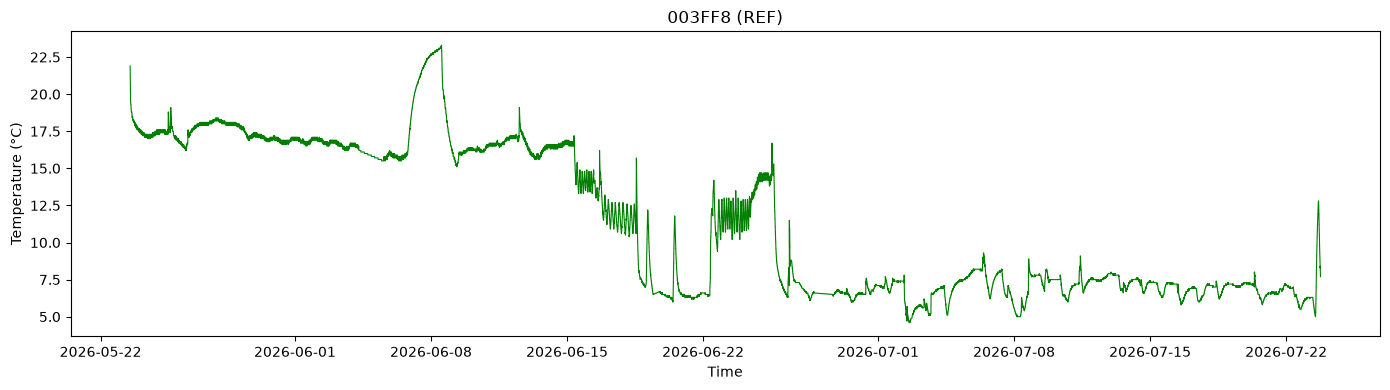

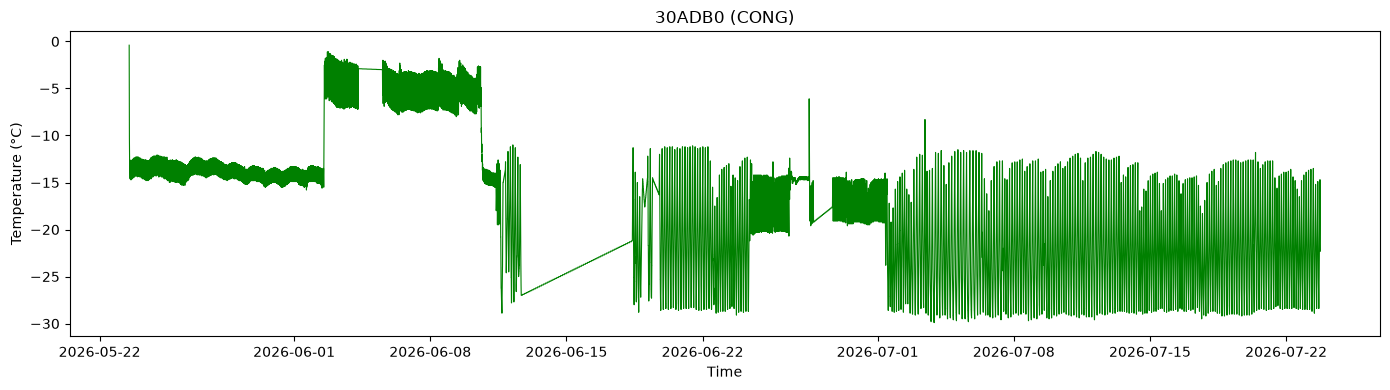

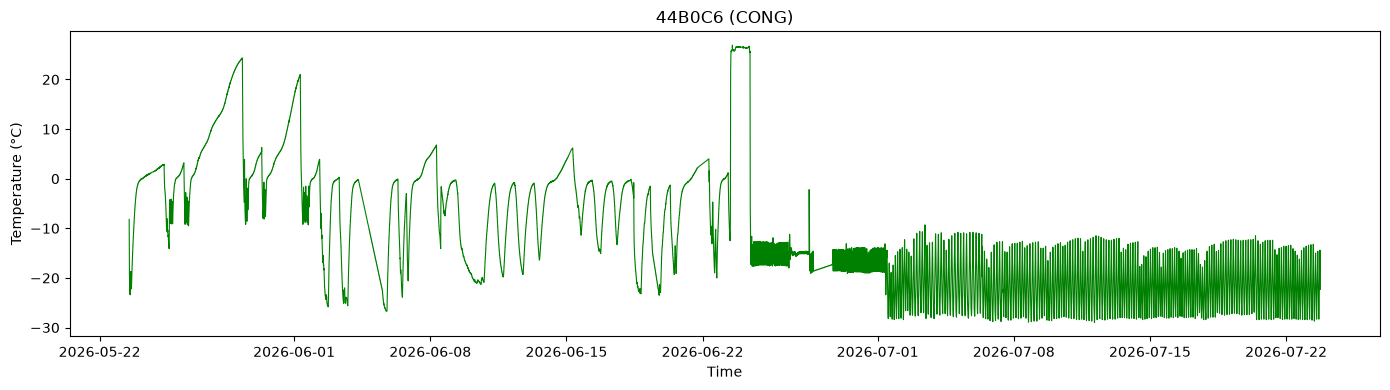

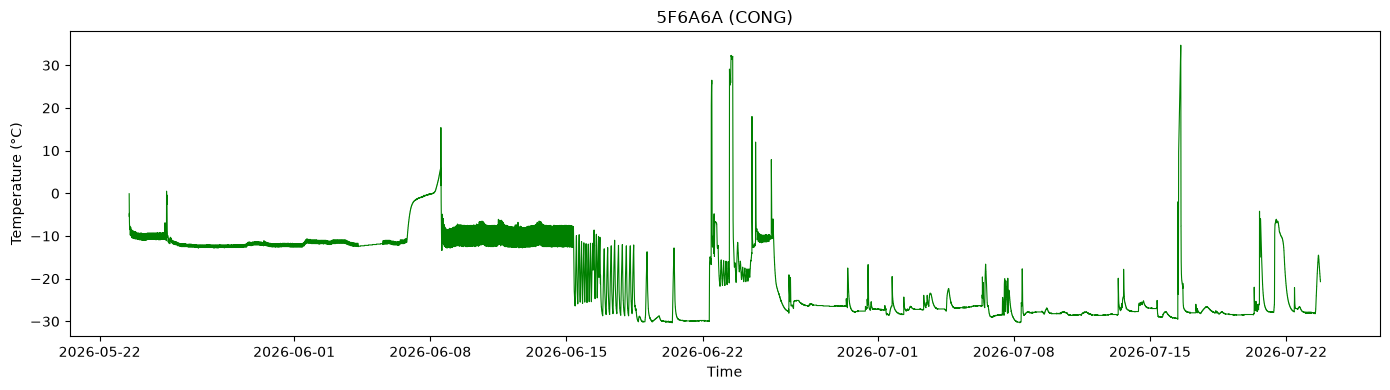

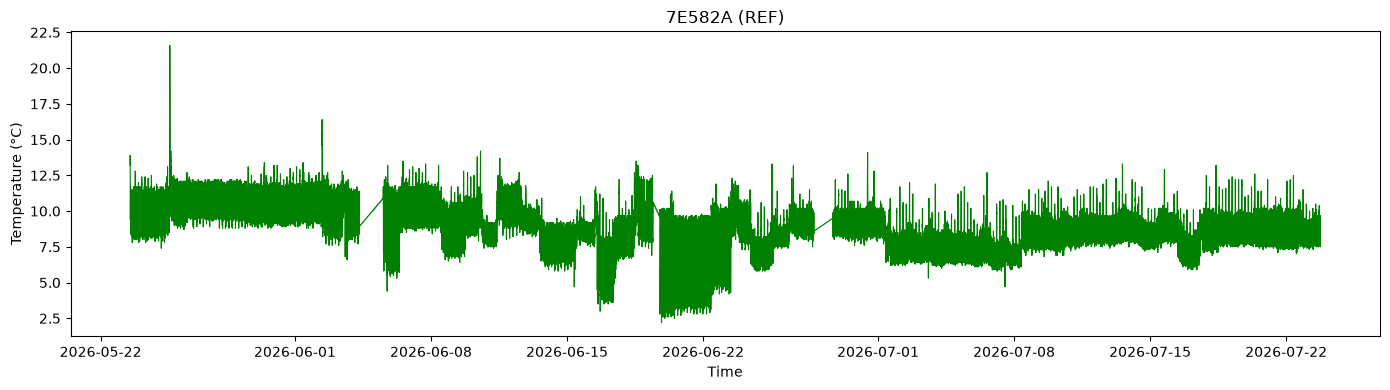

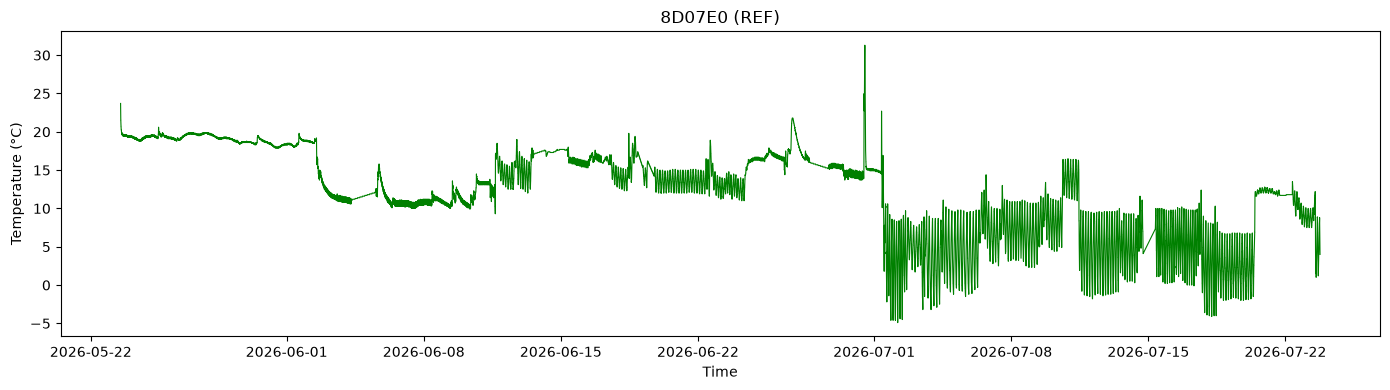

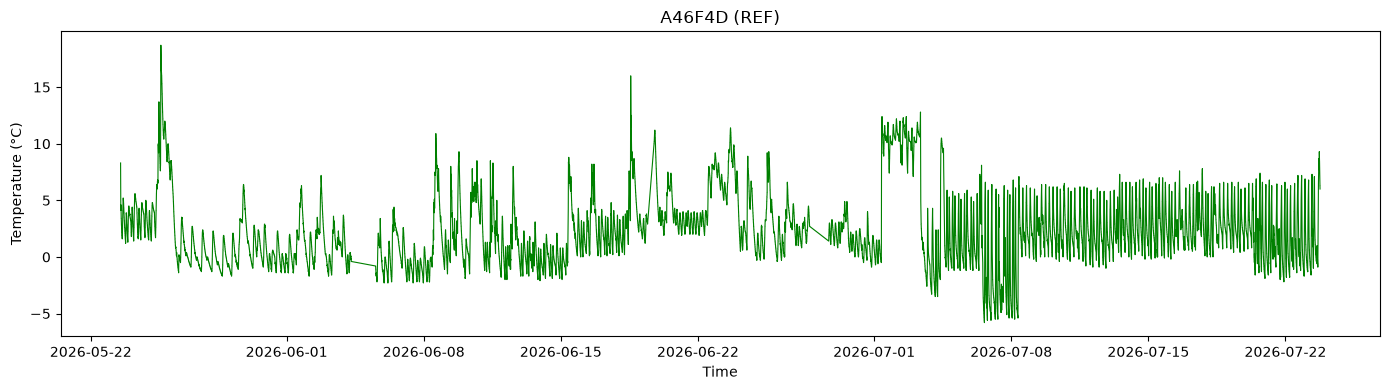

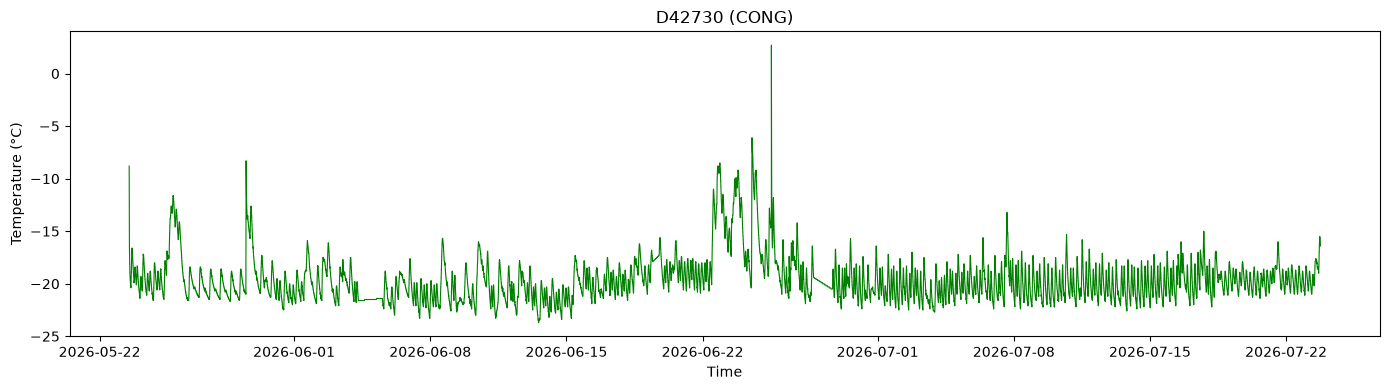

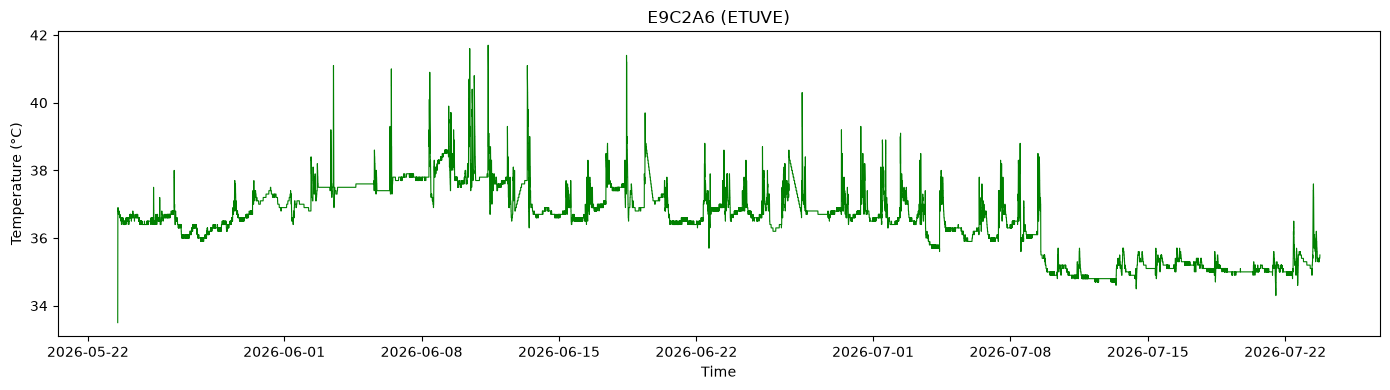

In [9]:
for device_id, group in all_data.groupby("device_id"):
    g = group.sort_values("Time")
    device_type = g["type"].iloc[0]

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(g["Time"], g["Temperature"], color="green", linewidth=0.8)
    ax.set_title(f"{device_id} ({device_type})")
    ax.set_xlabel("Time")
    ax.set_ylabel("Temperature (°C)")
    plt.tight_layout()
    plt.savefig(f"plots/{device_id}_temperature.png")
    plt.show()


## 7. Distribution comparée — boxplots

Par type, puis par device individuel.

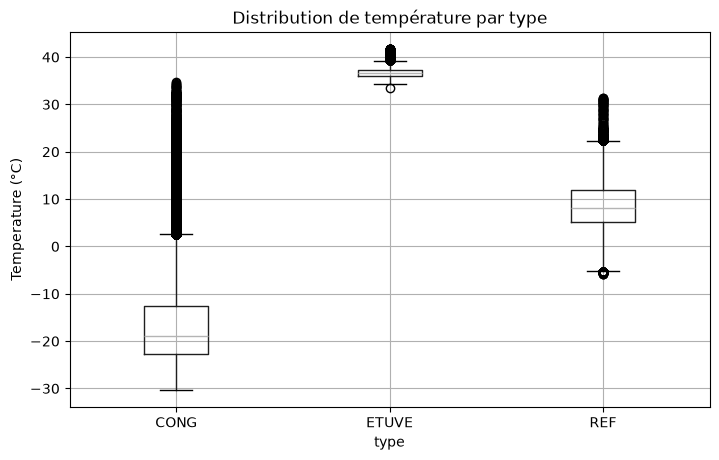

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
all_data.boxplot(column="Temperature", by="type", ax=ax)
ax.set_title("Distribution de température par type")
plt.suptitle("")
plt.ylabel("Temperature (°C)")
plt.savefig("plots/boxplot_by_type.png")
plt.show()


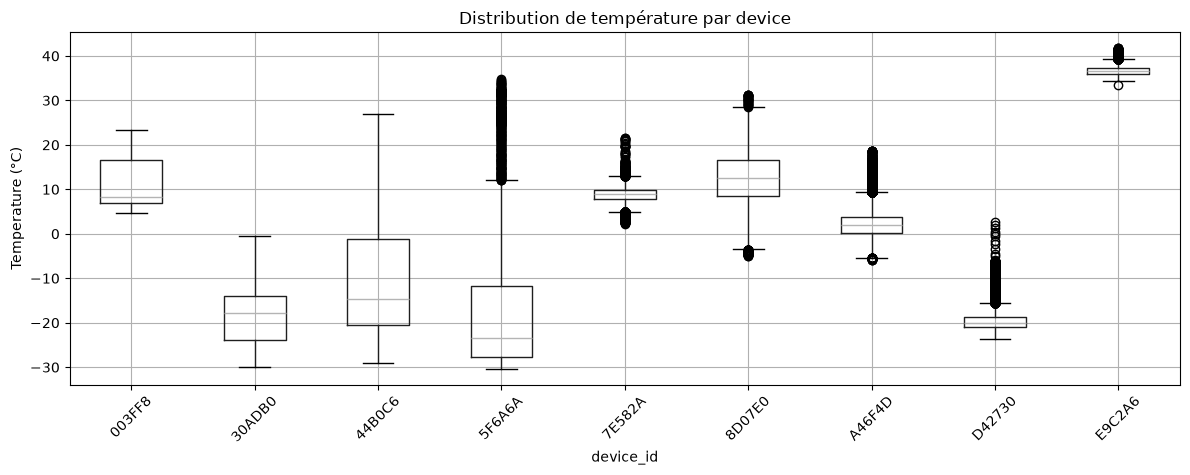

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
all_data.boxplot(column="Temperature", by="device_id", ax=ax, rot=45)
ax.set_title("Distribution de température par device")
plt.suptitle("")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.savefig("plots/boxplot_by_device.png")
plt.show()


## 8. Vitesse de changement (rate of change)

Calculée **par device** (jamais entre deux appareils différents), puis comparée par type. Utile pour justifier tout choix futur d'interpolation/lissage.

In [12]:
all_data_sorted = all_data.sort_values("Time")
all_data_sorted["temp_diff"] = all_data_sorted.groupby("device_id")["Temperature"].diff().abs()

print(all_data_sorted.groupby("type")["temp_diff"].agg(["mean", "median", "max"]))


           mean  median   max
type                         
CONG   0.075283     0.0  15.4
ETUVE  0.012092     0.0   3.1
REF    0.075013     0.0   5.7


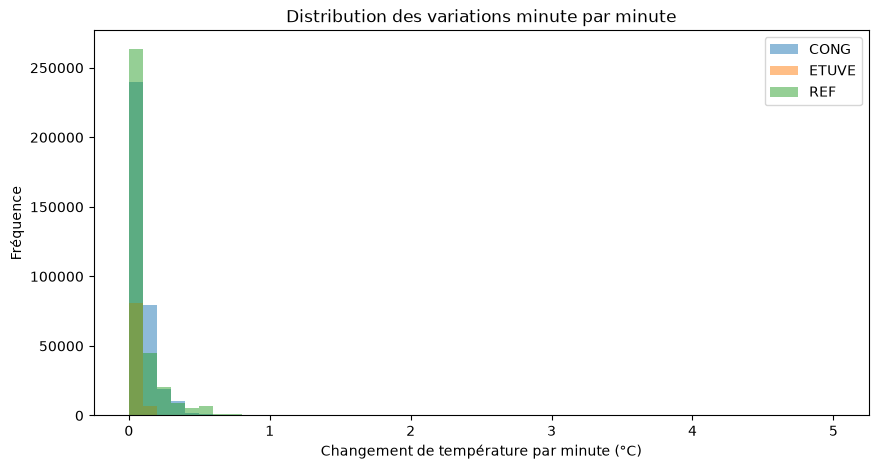

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
for device_type, group in all_data_sorted.groupby("type"):
    ax.hist(group["temp_diff"].dropna(), bins=50, alpha=0.5, label=device_type, range=(0, 5))
ax.set_xlabel("Changement de température par minute (°C)")
ax.set_ylabel("Fréquence")
ax.legend()
ax.set_title("Distribution des variations minute par minute")
plt.savefig("plots/temp_diff_histogram.png")
plt.show()


## 9. Zoom sur les excursions connues (5F6A6A, BEKO)

Repère d'abord automatiquement la période où la température est la plus extrême pour chaque device, puis zoome dessus. Ajuste les dates manuellement une fois la période repérée sur le plot complet ci-dessus.

5F6A6A - pic de température le : 2026-07-16 14:02:00 valeur : 34.7


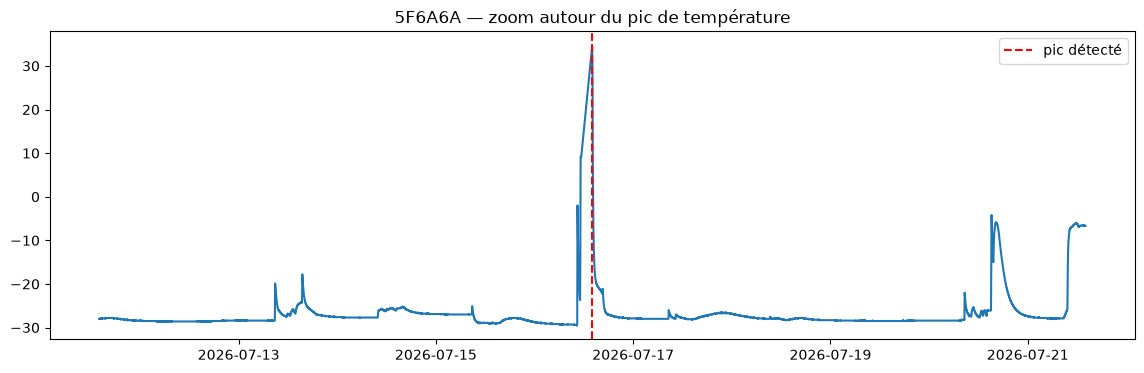

44B0C6 - pic de température le : 2026-06-23 12:45:00 valeur : 26.9


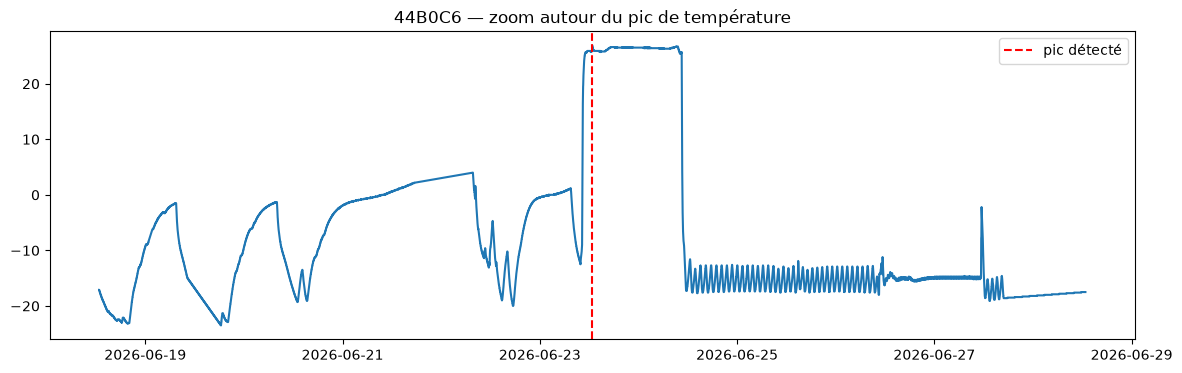

In [14]:
for device_id in ["5F6A6A", "44B0C6"]:
    g = all_data[all_data["device_id"] == device_id].sort_values("Time")
    idx_max = g["Temperature"].idxmax()
    peak_time = g.loc[idx_max, "Time"]
    print(device_id, "- pic de température le :", peak_time, "valeur :", g.loc[idx_max, "Temperature"])

    window = g[(g["Time"] >= peak_time - pd.Timedelta(days=5)) &
               (g["Time"] <= peak_time + pd.Timedelta(days=5))]

    plt.figure(figsize=(14, 4))
    plt.plot(window["Time"], window["Temperature"])
    plt.axvline(peak_time, color="red", linestyle="--", label="pic détecté")
    plt.title(f"{device_id} — zoom autour du pic de température")
    plt.legend()
    plt.savefig(f"plots/{device_id}_zoom_excursion.png")
    plt.show()


## 10. Corrélations entre capteurs (Temperature / humidity / battery)

Pertinent pour la couche autoencodeur plus tard (détection de corrélations anormales entre capteurs) — on vérifie d'abord si une vraie relation existe dans les données normales.

In [15]:
for device_id, group in all_data.groupby("device_id"):
    cols = [c for c in ["Temperature", "humidity", "battery"] if group[c].notna().sum() > 0]
    if len(cols) > 1:
        print(f"\n{device_id} :")
        print(group[cols].corr())



003FF8 :
             Temperature  humidity   battery
Temperature     1.000000  0.846447  0.881905
humidity        0.846447  1.000000  0.866735
battery         0.881905  0.866735  1.000000

30ADB0 :
             Temperature  humidity   battery
Temperature     1.000000  0.424484  0.811828
humidity        0.424484  1.000000  0.404956
battery         0.811828  0.404956  1.000000

44B0C6 :
             Temperature  humidity   battery
Temperature     1.000000  0.021881  0.913261
humidity        0.021881  1.000000 -0.126241
battery         0.913261 -0.126241  1.000000

5F6A6A :
             Temperature   battery
Temperature     1.000000  0.892442
battery         0.892442  1.000000

7E582A :
             Temperature   battery
Temperature     1.000000  0.597786
battery         0.597786  1.000000

8D07E0 :
             Temperature   battery
Temperature     1.000000  0.839503
battery         0.839503  1.000000

E9C2A6 :
             Temperature  humidity   battery
Temperature     1.000000 -0.50

## 11. Batterie faible vs lectures de température

Vérifie si une batterie faible coïncide avec des lectures de température suspectes pertinent pour distinguer panne de capteur vs événement physique réel (objectif de la Couche 3).

In [16]:
low_batt = all_data[all_data["battery"] < 20]
if len(low_batt) > 0:
    print("Lectures avec batterie < 20% :")
    print(low_batt.groupby("device_id")["Temperature"].describe())
else:
    print("Aucune lecture avec batterie < 20% trouvée.")


Lectures avec batterie < 20% :
             count       mean       std   min   25%   50%   75%   max
device_id                                                            
30ADB0     51455.0 -22.071750  4.755799 -29.9 -26.1 -22.8 -18.1  -8.3
44B0C6     39667.0 -20.867114  4.644303 -29.0 -25.2 -20.7 -17.1  -9.3
5F6A6A     42295.0 -27.236631  2.414877 -30.3 -28.4 -27.6 -26.5  12.7


In [18]:
import pandas as pd
all_data_clean = pd.read_csv("data/processed/all_data_clean.csv", parse_dates=["Time"])
print(all_data_clean.shape)
print(all_data_clean.columns)

(793755, 9)
Index(['Time', 'Temperature', 'humidity', 'battery', 'device_id', 'type',
       'temp_diff', 'suspicious_flat', 'sensor_group'],
      dtype='str')


In [19]:
def apply_baseline(df):
    df = df.copy()
    ranges = {
        "REF":   (2, 9),
        "CONG":  (-30, -20),
        "ETUVE": (35, 42),
    }

    low = df["type"].map(lambda t: ranges[t][0])
    high = df["type"].map(lambda t: ranges[t][1])

    df["baseline_anomaly"] = ~df["Temperature"].between(low, high)
    return df

all_data_clean = apply_baseline(all_data_clean)
print(all_data_clean.groupby("device_id")["baseline_anomaly"].sum())

device_id
003FF8    43220
30ADB0    52932
44B0C6    65093
5F6A6A    42363
7E582A    41337
8D07E0    70382
A46F4D    49411
D42730    43577
E9C2A6     4676
Name: baseline_anomaly, dtype: int64


In [ ]:
print(all_data_clean.groupby("device_id")["Temperature"].quantile([0.05, 0.95]))

device_id      
003FF8     0.05     6.000
           0.95    18.100
30ADB0     0.05   -28.200
           0.95    -4.100
44B0C6     0.05   -27.100
           0.95    11.300
5F6A6A     0.05   -29.600
           0.95    -7.700
7E582A     0.05     6.400
           0.95    11.500
8D07E0     0.05     1.100
           0.95    19.400
A46F4D     0.05    -1.400
           0.95     8.703
D42730     0.05   -22.000
           0.95   -15.600
E9C2A6     0.05    34.900
           0.95    37.900
Name: Temperature, dtype: float64


In [23]:
excursion_windows = {
    "44B0C6": ("2026-06-20", "2026-06-27"),
    "5F6A6A": ("2026-07-13", "2026-07-19"),
}

def get_clean_thresholds(df, excursion_windows, low_q=0.05, high_q=0.95):
    thresholds = {}
    for device_id, group in df.groupby("device_id"):
        g = group.copy()
        if device_id in excursion_windows:
            start, end = excursion_windows[device_id]
            g = g[~((g["Time"] >= start) & (g["Time"] <= end))]
        low = g["Temperature"].quantile(low_q)
        high = g["Temperature"].quantile(high_q)
        thresholds[device_id] = (low, high)
    return thresholds

device_thresholds = get_clean_thresholds(all_data_clean, excursion_windows)
for device_id, (low, high) in device_thresholds.items():
    print(device_id, ":", round(low, 1), "to", round(high, 1))

003FF8 : 6.0 to 18.1
30ADB0 : -28.2 to -4.1
44B0C6 : -27.3 to 7.4
5F6A6A : -29.8 to -7.6
7E582A : 6.4 to 11.5
8D07E0 : 1.1 to 19.4
A46F4D : -1.4 to 8.7
D42730 : -22.0 to -15.6
E9C2A6 : 34.9 to 37.9


In [24]:
def apply_baseline_per_device(df, thresholds):
    df = df.copy()
    df["baseline_anomaly"] = False

    for device_id, (low, high) in thresholds.items():
        mask = df["device_id"] == device_id
        df.loc[mask, "baseline_anomaly"] = ~df.loc[mask, "Temperature"].between(low, high)

    return df

all_data_clean = apply_baseline_per_device(all_data_clean, device_thresholds)

print(all_data_clean.groupby("device_id")["baseline_anomaly"].sum())
print("\n% flagged per device:")
print((all_data_clean.groupby("device_id")["baseline_anomaly"].mean() * 100).round(1))

device_id
003FF8    7685
30ADB0    8406
44B0C6    8973
5F6A6A    7298
7E582A    8290
8D07E0    8218
A46F4D    8563
D42730    8245
E9C2A6    6773
Name: baseline_anomaly, dtype: int64

% flagged per device:
device_id
003FF8     8.7
30ADB0     9.5
44B0C6    10.2
5F6A6A     8.3
7E582A     9.4
8D07E0     9.3
A46F4D     9.7
D42730     9.3
E9C2A6     7.7
Name: baseline_anomaly, dtype: float64


In [25]:
all_data_clean.to_csv("data/processed/all_data_with_baseline.csv", index=False)
print("Sauvegardé.")

Sauvegardé.


In [26]:
g = all_data[all_data["device_id"] == "5F6A6A"].sort_values("Time")
idx_max = g["Temperature"].idxmax()
print(g.loc[idx_max, "Time"], g.loc[idx_max, "Temperature"])

2026-07-16 14:02:00 34.7
